In [1]:
#primero importamos la liberia pandas
import pandas as pd
import numpy as np


In [2]:

#procedemos a leer los archivos y checar el tipo de datos que tenemos
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

#pasamos todo a formato snake_case con una función.

def dataclean(df):
    df.columns=(
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df
visits = dataclean(visits)
orders = dataclean(orders)
costs = dataclean(costs)

print(visits.head(5))
print('\n')
print(orders.head(5))
print('\n')
print(costs.head(5))


    device               end_ts  source_id             start_ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  


                buy_ts  revenue                   uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  201

In [3]:

#checamos los tipos de datos
print(visits.info(5))
print('\n')
print(orders.info(5))
print('\n')
print(costs.info(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   device     359400 non-null  object
 1   end_ts     359400 non-null  object
 2   source_id  359400 non-null  int64 
 3   start_ts   359400 non-null  object
 4   uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     -----------

In [4]:
#procedemos a convertir todos los valores de fecha (object) en formate date

visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

costs['dt'] = pd.to_datetime(costs['dt'])


In [5]:
# NULOS
print('Nulos visits:\n', visits.isna().sum())
print('\nNulos orders:\n', orders.isna().sum())
print('\nNulos costs:\n', costs.isna().sum())

# DUPLICADOS
print('\nDuplicados visits:', visits.duplicated().sum())
print('Duplicados orders:', orders.duplicated().sum())
print('Duplicados costs:', costs.duplicated().sum())

Nulos visits:
 device       0
end_ts       0
source_id    0
start_ts     0
uid          0
dtype: int64

Nulos orders:
 buy_ts     0
revenue    0
uid        0
dtype: int64

Nulos costs:
 source_id    0
dt           0
costs        0
dtype: int64

Duplicados visits: 0
Duplicados orders: 0
Duplicados costs: 0


¿Cuantas personas lo usan cada día, semana y mes?

In [6]:

visits['date']= visits['start_ts'].dt.floor('D')
daily_visits= visits.groupby('date')['uid'].nunique()

visits['year_week'] = visits['start_ts'].dt.to_period('W')
weekly_visits = visits.groupby('year_week')['uid'].nunique()

visits['year_month'] = visits['start_ts'].dt.to_period('M')
monthly_visits = visits.groupby('year_month')['uid'].nunique()

#si sumamos todos los valores cometemos el error de considerar al mismo usario 
#en el siguiente día por lo tanto es mejo usar el promedio.
print(f'lo usan por día {daily_visits.mean():.2f} usuarios')
print(f'lo usan por semana {weekly_visits.mean():.2f} usuarios')
print(f'lo usan por mes {monthly_visits.mean():.2f} usuarios')


lo usan por día 907.99 usuarios
lo usan por semana 5716.25 usuarios
lo usan por mes 23228.42 usuarios


In [7]:


daily_sessions = visits.groupby('date')['uid'].count()
weekly_sessions = visits.groupby('year_week')['uid'].count()
monthly_sessions = visits.groupby('year_month')['uid'].count()


print(f'las sesiones en promedio son {daily_sessions.mean():.2f} por día')
print(f'las sesiones en promedio son  {weekly_sessions.mean():.2f} por semana')
print(f'las sesiones en promedio son  {monthly_sessions.mean():.2f} por mes')

las sesiones en promedio son 987.36 por día
las sesiones en promedio son  6781.13 por semana
las sesiones en promedio son  29950.00 por mes


## *¿Cuál es la duración de cada sesión?*

In [8]:
visits['session_duration']=visits['end_ts']-visits['start_ts']
print(visits['session_duration'].describe())

count                       359400
mean     0 days 00:10:43.025687256
std      0 days 00:16:37.127760516
min              -1 days +23:14:00
25%                0 days 00:02:00
50%                0 days 00:05:00
75%                0 days 00:14:00
max                0 days 11:51:00
Name: session_duration, dtype: object


## ¿Con qué frecuencia los usuarios regresan?
*Para analizar con que frecuencia los usuarios regresan, necesitamos examinar el comportamiento de cada usuario individual a lo largo del tiempo.
Hay varias formas de medir esto:

### **Paso 1: Primero, veamos cuántas veces visita cada usuario**

In [9]:
user_visit_counts = visits.groupby('uid').size()
print("Distribución de número de visitas por usuario:")
print(user_visit_counts.describe())

Distribución de número de visitas por usuario:
count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64


### **Paso 2: Cuantas veces regresa un usuario**

In [10]:
single_visit_users = (user_visit_counts == 1).sum()
returning_users = (user_visit_counts > 1).sum()

print(f"Usuarios que visitaron solo una vez: {single_visit_users}")
print(f"Usuarios que regresaron: {returning_users}")

Usuarios que visitaron solo una vez: 176041
Usuarios que regresaron: 52128


### **También puedes revisarlo con un analisis de cohortes viendo su retención**

In [11]:
#crear mes de visita
visits['year_month'] = visits['start_ts'].dt.to_period('M')

#obtener la primera fecha de ingreso
first_visit = visits.groupby('uid')['year_month'].min()
visits['cohort'] = visits['uid'].map(first_visit) #<--map es como un vlookup de excel 

#calcular cuantos meses despues regresa
visits['cohort_index'] = (visits['year_month'] - visits['cohort']).apply(lambda x: x.n)

#crear tabla de cohortes
cohort_data = visits.groupby(['cohort', 'cohort_index'])['uid'].nunique().reset_index()

#convertirlas a tabla tipo matriz
cohort_table = cohort_data.pivot_table(
    index = 'cohort',
    columns = 'cohort_index',
    values = 'uid'
)
#convertir a retención
cohort_size = cohort_table[0]
retention = cohort_table.divide(cohort_size, axis=0)

print(retention*100)


cohort_index     0         1         2         3         4         5   \
cohort                                                                  
2017-06       100.0  7.866355  5.377479  6.139226  6.855721  7.142318   
2017-07       100.0  5.608828  5.129376  5.616438  5.821918  4.817352   
2017-08       100.0  7.690797  6.286219  6.276397  5.009331  4.400354   
2017-09       100.0  8.548851  6.920498  5.070642  3.939176  3.783525   
2017-10       100.0  7.860800  5.223852  3.895754  3.426108  3.222081   
2017-11       100.0  7.828097  4.411333  3.868174  3.372725  2.341456   
2017-12       100.0  5.580180  3.799272  3.110654  2.026278  1.903593   
2018-01       100.0  5.971535  3.933876  2.497348  2.024399       NaN   
2018-02       100.0  5.707979  2.545389  2.009281       NaN       NaN   
2018-03       100.0  4.181845  2.705328       NaN       NaN       NaN   
2018-04       100.0  4.837991       NaN       NaN       NaN       NaN   
2018-05       100.0       NaN       NaN       NaN  

In [12]:
#necesitamos obtener las primeras visitas de los clientes
first_visit_user = visits.groupby('uid')['start_ts'].min().reset_index()

#también debemos obtener la fecha de la primera compra de los usuarios
first_buy = orders.groupby('uid')['buy_ts'].min().reset_index()

#ahora tenemos que juntar las tablas para comparar las fechas
users_process = first_visit_user.merge(first_buy, on='uid', how='inner' ) 

#ahora vamos a calcular cuanto se tarda cada cliente en relizar su primera compra
users_process['time_to_purchase'] =users_process['buy_ts']-users_process['start_ts'] 

print(f"el tiempo promedio que tardan en comprar es de {users_process['time_to_purchase'].mean()}")
print(f"el tiempo mínimo que tardaron en comprar es de {users_process['time_to_purchase'].min()}")
print(f"el tiempo máximo que tardaron en comprar es de {users_process['time_to_purchase'].max()}")

el tiempo promedio que tardan en comprar es de 16 days 21:40:10.550064343
el tiempo mínimo que tardaron en comprar es de 0 days 00:00:00
el tiempo máximo que tardaron en comprar es de 363 days 07:04:00


In [13]:


#Primero hay que convertir el tiempo que se tardan en comprar en días
users_process['conversion_days'] = users_process['time_to_purchase'].dt.days

#crear cohorte (mes de registro)
users_process['cohort'] = users_process['start_ts'].dt.to_period('M')

#crear tablas tipo cohortes
cohort_conversion = users_process.groupby(
    ['cohort', 'conversion_days']
)['uid'].count().reset_index()

#hacer una tabla dinamica o pivot table

cohort_table = cohort_conversion.pivot_table(
    index = 'cohort',
    columns = 'conversion_days',
    values = 'uid'
)

#se calcula el porcentaje de retención de conversión
cohort_size = cohort_table.sum(axis=1)
conversion_rate = cohort_table.divide(cohort_size, axis=0) * 100

print(conversion_rate.round(2))



conversion_days    0     1     2     3     4     5     6     7     8     9    \
cohort                                                                         
2017-06          61.72  1.88  0.92  1.16  0.72  0.51  0.55  0.34  0.48  0.21   
2017-07          62.08  2.40  1.51  0.77  0.81  0.69  0.53  0.49  0.45  0.20   
2017-08          63.74  1.57  0.81  0.70  0.93  0.52  0.70  0.41  0.29  0.23   
2017-09          64.29  2.32  1.28  1.31  0.98  0.78  1.14  0.56  0.56  0.46   
2017-10          70.59  2.52  1.50  1.24  0.66  0.79  0.68  0.58  0.43  0.32   
2017-11          67.25  3.40  1.71  1.53  0.99  0.77  0.77  0.56  0.59  0.54   
2017-12          73.44  3.07  1.67  1.50  1.01  0.91  0.64  0.74  0.52  0.44   
2018-01          74.58  3.01  1.70  1.22  0.93  0.93  0.80  0.61  0.58  0.48   
2018-02          77.90  2.98  2.32  1.26  1.26  0.78  0.56  1.10  0.56  0.53   
2018-03          83.47  2.85  1.48  0.81  0.78  0.74  0.63  0.42  0.74  0.18   
2018-04          82.38  3.23  1.64  1.38

¿Cuantos pedidos hacen durante un periodo de tiempo?



In [14]:
orders_per_month = orders.groupby(
    orders['buy_ts'].dt.to_period('M')
)['uid'].count()

print(f" los pedidos en promedio hechos al mes son {orders_per_month.mean().round(2)}")

 los pedidos en promedio hechos al mes son 3878.08


¿Cual es el tamaño promedio de la compra?

In [15]:
aov = orders['revenue'].mean()
print("el tamañano promedio de la compra es:")
print(aov.round(2))

el tamañano promedio de la compra es:
5.0


**¿Cuanto dinero traen (LTV)? (LTV acumulativo)**


In [16]:

orders['order_month'] = orders['buy_ts'].dt.to_period('M')

first_order = orders.groupby('uid')['order_month'].min()
orders['cohort'] = orders['uid'].map(first_order)

orders['cohort_index'] = (
    orders['order_month'] - orders['cohort']
).apply(lambda x: x.n)

cohort_revenue = orders.groupby(
    ['cohort', 'cohort_index']
)['revenue'].sum().reset_index()

cohort_users = orders.groupby('cohort')['uid'].nunique()

cohort_table = cohort_revenue.pivot_table(
    index='cohort',
    columns='cohort_index',
    values='revenue'
)

ltv_cohort = cohort_table.divide(cohort_users, axis=0)
ltv_cumulative = ltv_cohort.cumsum(axis=1)
print(ltv_cumulative.round(2))


cohort_index    0     1     2      3      4      5      6      7      8   \
cohort                                                                     
2017-06       4.72  5.21  5.65   6.60   7.62   8.36   9.31   9.89  10.45   
2017-07       6.01  6.35  6.97   7.33   7.50   7.66   7.78   7.92   8.08   
2017-08       5.28  5.75  6.21   6.60   7.09   7.38   7.59   7.99   8.28   
2017-09       5.64  6.76  7.28  11.26  11.66  12.31  13.01  13.25  13.44   
2017-10       5.00  5.54  5.73   5.89   6.04   6.16   6.24   6.36    NaN   
2017-11       5.15  5.55  5.75   6.08   6.23   6.28   6.40    NaN    NaN   
2017-12       4.74  5.00  5.92   6.99   7.30   7.64    NaN    NaN    NaN   
2018-01       4.14  4.43  4.73   4.88   4.94    NaN    NaN    NaN    NaN   
2018-02       4.16  4.44  4.51   4.59    NaN    NaN    NaN    NaN    NaN   
2018-03       4.84  5.14  5.46    NaN    NaN    NaN    NaN    NaN    NaN   
2018-04       4.66  5.19   NaN    NaN    NaN    NaN    NaN    NaN    NaN   
2018-05     

## **MARKETING**

## ¿Cuanto dinero gastó?

In [17]:
total_costs = costs['costs'].sum()
print(f"Gasto total: {total_costs:.2f}")

Gasto total: 329131.62


## ROMI por fuente

In [18]:

costs_by_source = costs.groupby('source_id', as_index=False).agg({
    'costs': 'sum'
})
print(costs_by_source)

   source_id      costs
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
5          9    5517.49
6         10    5822.49


In [19]:
costs['month'] = costs['dt'].dt.to_period('M')

costs_over_time = costs.groupby('month', as_index=False).agg({
    'costs': 'sum'
})
print(costs_over_time)

      month     costs
0   2017-06  18015.00
1   2017-07  18240.59
2   2017-08  14790.54
3   2017-09  24368.91
4   2017-10  36322.88
5   2017-11  37907.88
6   2017-12  38315.35
7   2018-01  33518.52
8   2018-02  32723.03
9   2018-03  30415.27
10  2018-04  22289.38
11  2018-05  22224.27


In [20]:

#primera visita por usuario
first_visits = visits.sort_values('start_ts').drop_duplicates('uid')
first_visits['cohort'] = first_visits['start_ts'].dt.to_period('M')

#usuarios por fuente y cohorte
users_by_source_cohort = first_visits.groupby(
    ['source_id', 'cohort'],
    as_index=False
).agg({'uid': 'nunique'})

#costos por fuente y mes
costs_by_source_month = costs.groupby(
    ['source_id', 'month'],
    as_index=False
).agg({'costs': 'sum'})

#Cac
cac = users_by_source_cohort.merge(
    costs_by_source_month,
    left_on=['source_id', 'cohort'],
    right_on=['source_id', 'month'],
    how='left'
)

cac['cac'] = cac['costs'] / cac['uid']

print(cac[['source_id', 'cohort', 'cac']])


    source_id   cohort       cac
0           1  2017-06  1.783851
1           1  2017-07  1.986815
2           1  2017-08  2.593488
3           1  2017-09  2.189519
4           1  2017-10  2.243944
..        ...      ...       ...
93         10  2018-01  0.819133
94         10  2018-02  0.571116
95         10  2018-03  0.561804
96         10  2018-04  0.870516
97         10  2018-05  0.690000

[98 rows x 3 columns]


In [21]:
# primera visita
first_visits = visits.sort_values('start_ts').drop_duplicates('uid')
first_visits['cohort'] = first_visits['start_ts'].dt.to_period('M')

# usuarios por fuente y cohorte
users_by_source_cohort = first_visits.groupby(
    ['source_id', 'cohort'],
    as_index=False
).agg(users=('uid', 'nunique'))  

costs_by_source_month = costs.groupby(
    ['source_id', 'month'],
    as_index=False
).agg(total_costs=('costs', 'sum'))

# merge
cac = users_by_source_cohort.merge(
    costs_by_source_month,
    left_on=['source_id', 'cohort'],
    right_on=['source_id', 'month'],
    how='left'
)

# CAC
cac['cac'] = cac['total_costs'] / cac['users']

# limpieza opcional
cac = cac.drop(columns=['month'])

print(cac)

    source_id   cohort  users  total_costs       cac
0           1  2017-06    631      1125.61  1.783851
1           1  2017-07    540      1072.88  1.986815
2           1  2017-08    367       951.81  2.593488
3           1  2017-09    686      1502.01  2.189519
4           1  2017-10   1032      2315.75  2.243944
..        ...      ...    ...          ...       ...
93         10  2018-01    750       614.35  0.819133
94         10  2018-02    842       480.88  0.571116
95         10  2018-03    937       526.41  0.561804
96         10  2018-04    446       388.25  0.870516
97         10  2018-05    594       409.86  0.690000

[98 rows x 5 columns]


In [22]:
#en esta parte se hace uhna limpieza ya que cometi error de hacer merge varias veces y me quedaron columnas como 'cohort_x, source_id_y'
orders = orders.merge(
    first_visits[['uid', 'source_id', 'cohort']],
    on='uid',
    how='left'
)
orders = orders.loc[:, ~orders.columns.duplicated()]
orders = orders.drop(columns=[
    'cohort_y',
    'source_id_y'
], errors='ignore')
orders = orders.rename(columns={'cohort_x': 'cohort'})
orders = orders.drop(columns=['source_id_x'], errors='ignore')
print(orders.columns)
print(orders['cohort'].dtype)
print(cac.columns)

Index(['buy_ts', 'revenue', 'uid', 'order_month', 'cohort', 'cohort_index',
       'source_id'],
      dtype='object')
period[M]
Index(['source_id', 'cohort', 'users', 'total_costs', 'cac'], dtype='object')


In [26]:
#ganancias por cohortes
revenue_cohorts = orders.groupby(
    ['source_id', 'cohort', 'cohort_index'],
    as_index=False
).agg(revenue=('revenue', 'sum'))

#merge con costos
romi = revenue_cohorts.merge(
    cac[['source_id', 'cohort', 'total_costs']],
    on=['source_id', 'cohort'],
    how='left'
)

#costos solo en mes 0
romi['cost'] = 0
romi.loc[romi['cohort_index'] == 0, 'cost'] = romi['total_costs']

#acumulados
romi['cum_revenue'] = romi.groupby(
    ['source_id', 'cohort']
)['revenue'].cumsum()

romi['cum_cost'] = romi.groupby(
    ['source_id', 'cohort']
)['cost'].cumsum()

#romi final
romi['romi'] = (
    (romi['cum_revenue'] - romi['cum_cost']) / romi['cum_cost']
)

romi['romi'] = romi['romi'].replace([np.inf, -np.inf], np.nan)

romi_pivot = romi.pivot_table(
    index=['source_id', 'cohort'],
    columns='cohort_index',
    values='romi'
)
print(romi_pivot)

cohort_index             0         1         2         3         4         5   \
source_id cohort                                                                
1         2017-06  0.224847  0.593518  0.966143  1.600679  2.321355  2.667247   
          2017-07  0.087447  0.250848  1.049390  1.274131  1.405115  1.539315   
          2017-08 -0.110379  0.031761  0.151700  0.266240  0.389626  0.468739   
          2017-09 -0.090991  0.181317  0.265844  0.405616  0.411475  0.425883   
          2017-10 -0.116342  0.038674  0.074611  0.131551  0.140840  0.156727   
...                     ...       ...       ...       ...       ...       ...   
10        2018-01 -0.535916 -0.533637 -0.523187       NaN       NaN       NaN   
          2018-02 -0.367264 -0.337610 -0.336591       NaN       NaN       NaN   
          2018-03  0.212819  0.236964  0.248912       NaN       NaN       NaN   
          2018-04 -0.325357       NaN       NaN       NaN       NaN       NaN   
          2018-05  0.148905 

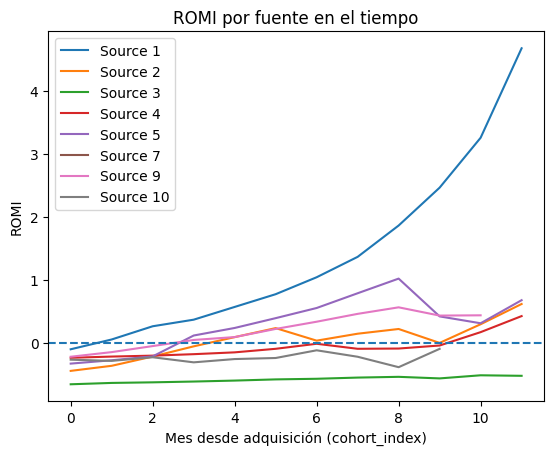

In [27]:
import matplotlib.pyplot as plt

for source in romi['source_id'].unique():
    subset = romi[romi['source_id'] == source]
    
    plt.plot(
        subset.groupby('cohort_index')['romi'].mean(),
        label=f'Source {source}'
    )

plt.axhline(0, linestyle='--')  # punto de equilibrio
plt.xlabel('Mes desde adquisición (cohort_index)')
plt.ylabel('ROMI')
plt.title('ROMI por fuente en el tiempo')
plt.legend()
plt.show()

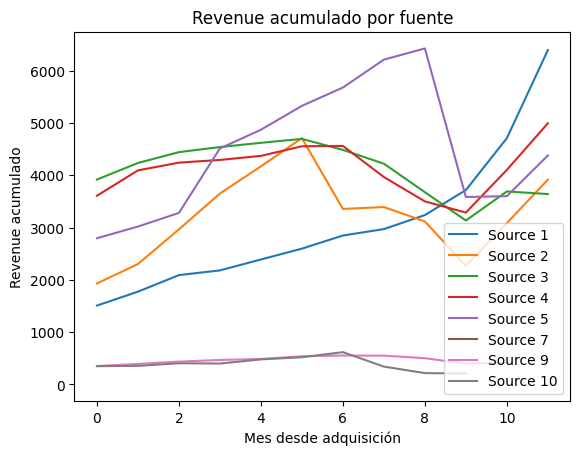

In [28]:
for source in romi['source_id'].unique():
    subset = romi[romi['source_id'] == source]
    
    plt.plot(
        subset.groupby('cohort_index')['cum_revenue'].mean(),
        label=f'Source {source}'
    )

plt.xlabel('Mes desde adquisición')
plt.ylabel('Revenue acumulado')
plt.title('Revenue acumulado por fuente')
plt.legend()
plt.show()

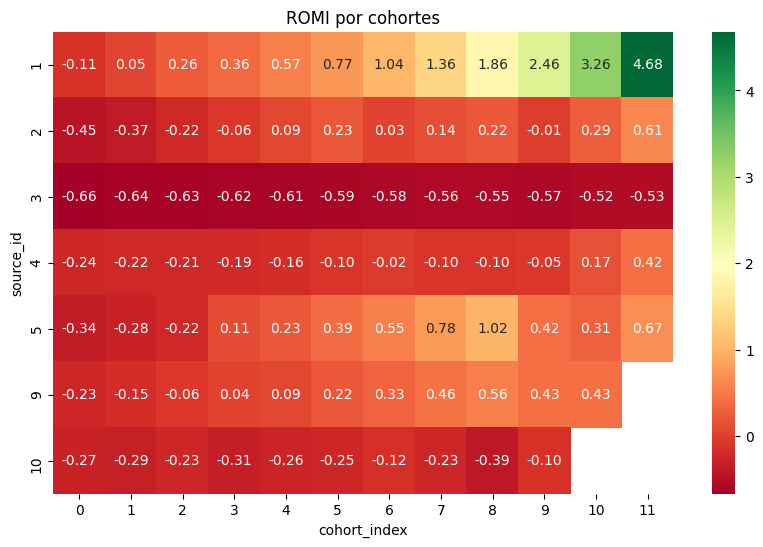

In [29]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    romi.pivot_table(
        index='source_id',
        columns='cohort_index',
        values='romi'
    ),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn"
)

plt.title('ROMI por cohortes')
plt.show()

 **Conclusión y recomendaciones de inversión**

Después de analizar el desempeño de las distintas fuentes de adquisición, evalué tres métricas clave: Revenue, CAC y ROMI, además de apoyarme en el LTV por cohorte para entender el valor a largo plazo de los usuarios.

**Hallazgos principales**

Algunas fuentes generan alto volumen de ingresos, pero también presentan un CAC elevado, lo que reduce su rentabilidad.

El ROMI se calculó de forma acumulada por cohortes, asignando el costo de adquisición únicamente al periodo inicial. Esto permite observar en qué momento cada cohorte recupera la inversión y comienza a generar ganancias.

Otras fuentes, aunque traen menos volumen, muestran un ROMI positivo y estable, lo que indica una inversión más eficiente.

El análisis de cohortes (LTV) muestra que no todas las fuentes generan usuarios de igual calidad: algunas cohortes incrementan su valor con el tiempo, mientras que otras se estancan rápidamente.

 **Métricas clave utilizadas**

CAC (Costo de Adquisición): para entender cuánto cuesta adquirir un cliente por canal

ROMI: para evaluar la rentabilidad directa de la inversión

LTV: para medir el valor real del cliente a lo largo del tiempo

Revenue total: para dimensionar el impacto en ingresos

Me enfoqué especialmente en ROMI y LTV/CAC, ya que:

ROMI indica si una campaña es rentable en el corto plazo

LTV/CAC muestra sostenibilidad en el largo plazo

 **3. Recomendaciones**

Invertir más en las fuentes con ROMI positivo y alto LTV/CAC
→ Son los canales más eficientes y escalables

Optimizar (no eliminar) las fuentes con alto revenue pero bajo ROMI
→ Ajustar segmentación, creativos o costos

Reducir o pausar inversión en fuentes con ROMI negativo
→ No generan retorno suficiente

Priorizar dispositivos con mejor conversión (ej. desktop vs mobile si aplica)
→ Reasignar presupuesto según desempeño

**Conclusión final**

La estrategia óptima no es invertir en los canales que generan más volumen, sino en aquellos que generan mayor rentabilidad y valor a largo plazo.

Por lo tanto, recomendaría una redistribución del presupuesto hacia las fuentes con mejor desempeño en ROMI y LTV, manteniendo un monitoreo constante para optimizar campañas menos eficientes.

**Insight clave**

No todos los usuarios valen lo mismo: las mejores decisiones de inversión se toman cuando se analiza no solo cuánto compran, sino cuánto valor generan en el tiempo.